In [1]:
%load_ext autoreload
%autoreload 2

import os
# Workaround for Mac M1 OpenMP conflict when loading torch
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

#import pytorch_lightning as pl
import pandas as pd
import numpy as np
import pickle


from scipy import stats

import matplotlib.pyplot as plt

from pytorch_lightning import Trainer
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import ModelCheckpoint

from footprinting import plot_count_matrix, get_count_matrix, average_counts_by_fraglen, get_footprint_and_procap, get_valid_windows, detect_blobs_matrix, detect_footprints, read_footprints_tsv, get_scale_factors

from datasets import FootprintDataModule
from models    import UNetLightning
from functools import partial
import wandb


In [ ]:
# Define test input data 
#counts_gz = '../data/MicroC_3hrDMSO.counts.tsv.gz'
#counts_gz = '../data/mesc_microC_3hrDMSO_chr8.counts.tsv.gz'
counts_gz = '../test_data/mesc_microc_test.counts.tsv.gz'
procap_bw = '../data/GSM2170014_Pro_mESC.ucsc_mm10.bw'

chrom = 'chr8'

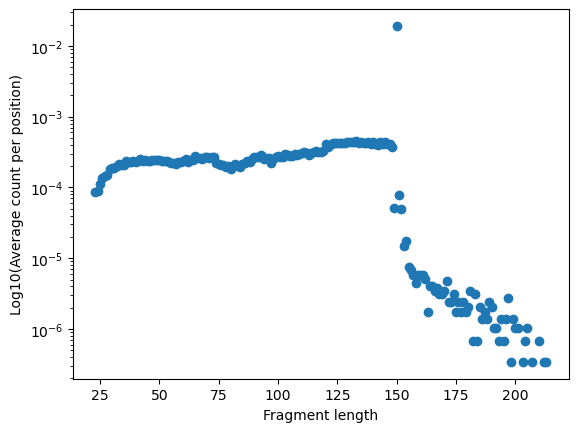

In [ ]:
# Get raw normalization factors (i.e. average counts per fragment length)
#avg_by_len = average_counts_by_fraglen(counts_gz, chrom, gap_thresh=5000, num_regions=500, region_size=5000, by_fragment_length=True)
avg_by_len = get_scale_factors(counts_gz, by_fragment_length=True)

# Plot log10(avg_by_len) - scatter plot
plt.scatter(avg_by_len.keys(), list(avg_by_len.values()))
plt.yscale('log')
plt.xlabel('Fragment length')
plt.ylabel('Log10(Average count per position)')
plt.show()


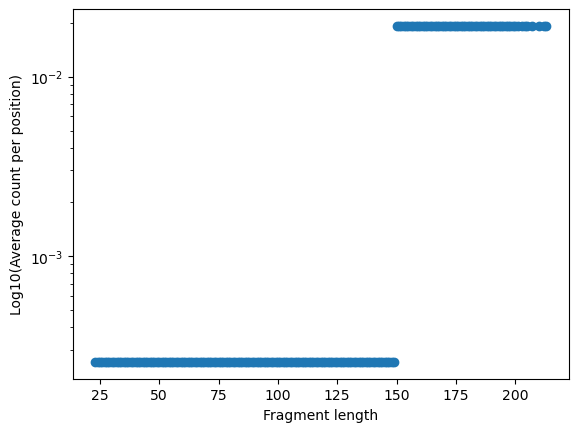

In [8]:
# Get normalization factors 
avg_by_len = get_scale_factors(counts_gz)

# Plot log10(avg_by_len) - scatter plot
plt.scatter(avg_by_len.keys(), list(avg_by_len.values()))
plt.yscale('log')
plt.xlabel('Fragment length')
plt.ylabel('Log10(Average count per position)')
plt.show()


[('chr8', 23230000, 23230999), ('chr8', 23231000, 23231999), ('chr8', 23232000, 23232999), ('chr8', 23233000, 23233999), ('chr8', 23234000, 23234999), ('chr8', 23235000, 23235999), ('chr8', 23236000, 23236999), ('chr8', 23237000, 23237999), ('chr8', 23238000, 23238999), ('chr8', 23239000, 23239999)]


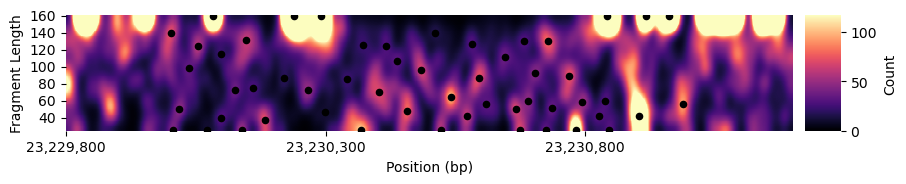

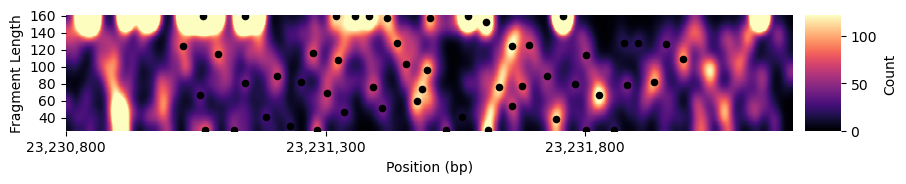

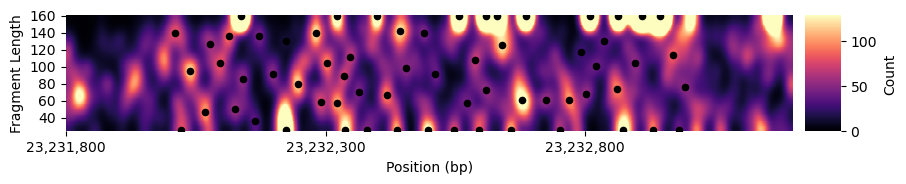

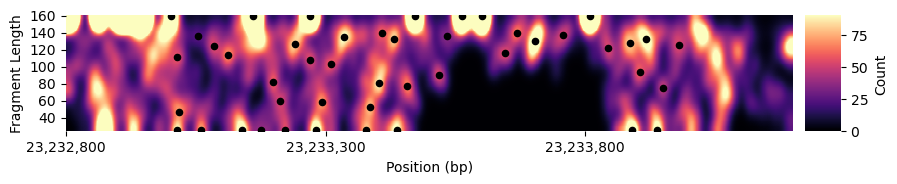

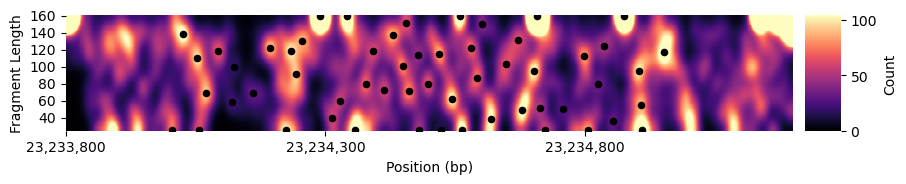

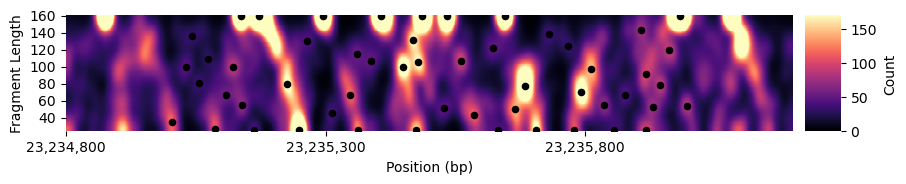

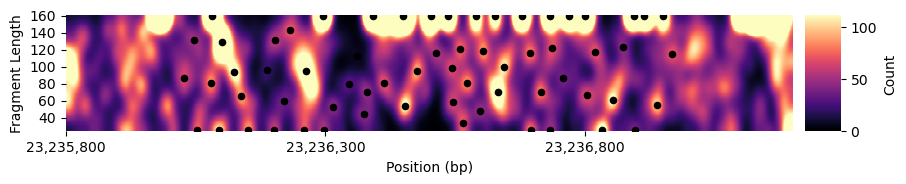

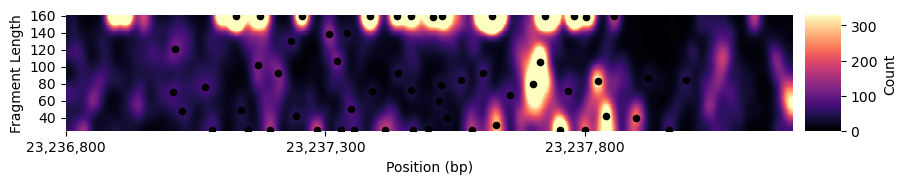

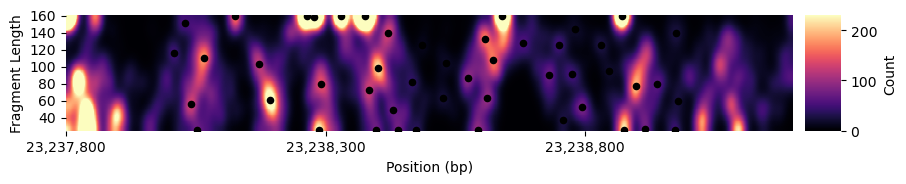

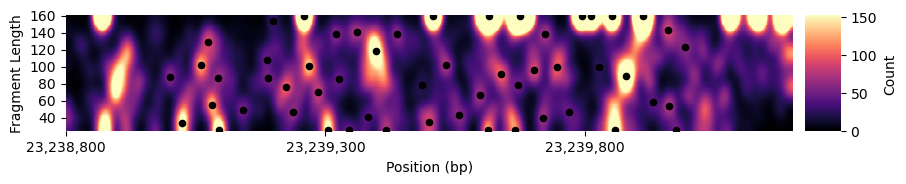

   fragment_length  position    size   max_signal  mean_signal   total_signal
0              160  23230238  4822.0  1243.918146   163.304026  787452.011567
1              160  23230842  6235.0   981.732741   102.059746  636342.516050
2              160  23230290  5253.0   742.329209   105.541850  554411.336428
3              160  23230961  2922.0   656.005294   106.757932  311946.678482
4              160  23230916  1523.0   564.606506   144.057494  219399.563563


In [13]:
# Loop over a set of windows 

# Set parameters for blob detection
threshold = 5  # Minimum signal intensity to be considered part of a blob
sigma = 10.0       # Standard deviation for Gaussian smoothing
min_size = 5      # Minimum blob size in pixels

chrom = 'chr8'
start_bp = 23_230_000
end_bp = 23_240_000

window_size = 1000
pad = 200

# Make windows from window_start_bp to end_bp with a 500bp overlap
windows = []
for i in range(start_bp, end_bp, window_size):
    windows.append((chrom, i, i+window_size-1))

print(windows)

# Loop over windows
# Initialize blobs as an empty DataFrame before the loop (outside the loop)
footprints = pd.DataFrame()

for chrom, window_start, window_end in windows:
    footprint, _ = get_count_matrix(counts_gz, chrom, window_start-pad, window_end+pad, fragment_len_min=25, fragment_len_max=160, sigma=10, scale="by_fragment_length")
    # Detect blobs in the footprint matrix
    window_blobs = detect_blobs_matrix(
        footprint_matrix=footprint,
        threshold=threshold, min_size=min_size
    )
    # Subset to blobs within (unpadded) window
    window_blobs = window_blobs[(window_blobs['position'] >= window_start) & (window_blobs['position'] <= window_end)]
    # Append window_blobs to blobs
    footprints = pd.concat([footprints, window_blobs], ignore_index=True)
    
    plot_count_matrix(footprint, blobs=window_blobs, blob_marker='o', blob_color='black', blob_size=20, 
                      xtick_spacing=500, figsize=(10, 1.5))

print(footprints.head())


In [7]:
# Detect footprints in a larger region
footprints = detect_footprints(counts_gz, chromosomes=[(chrom, 20_000_000, 30_000_000)], window_size=10000, pad=200, threshold=5, sigma=10, min_size=5, 
                               fragment_len_min=25, fragment_len_max=160, scale_factor_dict=avg_by_len, num_cores=8)

Getting valid windows...
Processing 858 windows using 8 cores...


Detecting footprints:  60%|█████▉    | 512/858 [00:13<00:10, 34.35it/s]/Users/martin/miniforge3/envs/footprint-tools/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Detecting footprints: 100%|██████████| 858/858 [00:20<00:00, 42.53it/s]


Detected 18132 footprints across 858 windows.


   max_signal   p_value   q_value
0   16.201930  0.000386  0.035316
1    9.282320  0.062533  0.529591
2    7.809256  0.172855  0.758094
3    6.541578  0.400147  0.915836
4    6.232086  0.487529  0.946535
5    5.937856  0.585981  0.969595
6    5.155487  0.926624  0.995282
7    5.149948  0.929351  0.995282
8    5.035485  0.984753  0.995282
9    5.014862  0.994036  0.995480
Number significant at 5% FDR: 236
Number significant at 10% FDR: 363


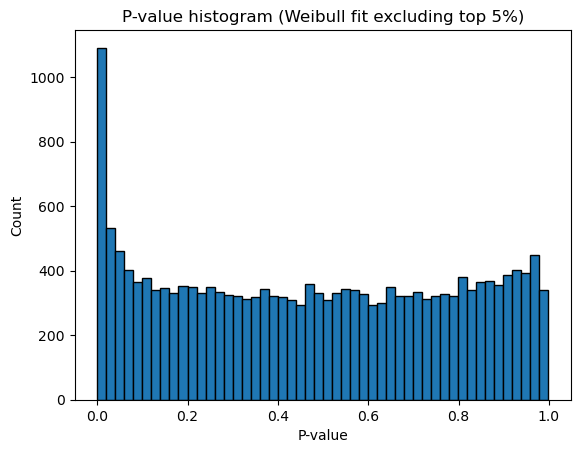

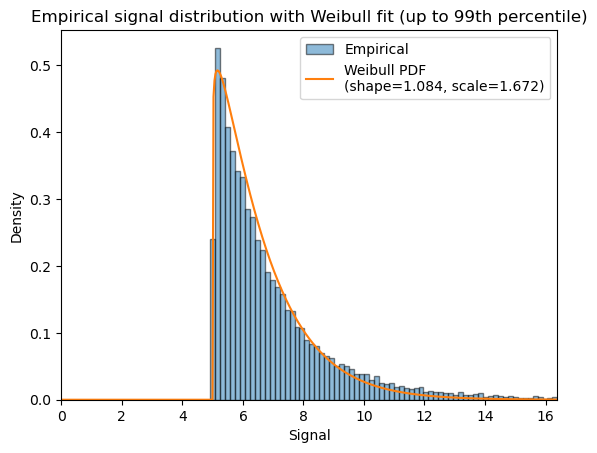

In [8]:
# Fit a Weibull distribution to the max_signal values and use it to compute p-values


# 1. 
values = footprints['max_signal'].values 

# If there are more than 100,000 footprints, use a random subsample
value_sample = values if len(values) <= 100_000 else np.random.choice(values, 100_000, replace=False)

# 2. Grid search over specified exclusion fractions
candidates = [0.05, 0.10, 0.20, 0.30]
results = []
for f in candidates:
    thr = np.percentile(values, 100 * (1 - f))
    bulk = value_sample[value_sample <= thr]
    shape, loc, scale = stats.weibull_min.fit(bulk, floc=threshold)
    p_bulk = 1 - stats.weibull_min.cdf(bulk, shape, loc=threshold, scale=scale)
    ks_stat, _ = stats.kstest(p_bulk, 'uniform')
    results.append((f, thr, shape, scale, ks_stat))

# 3. Select best fraction (min KS statistic)
best_f, best_thr, best_shape, best_scale, best_ks = min(results, key=lambda x: x[4])

# 4. Refit on bulk with best fraction
bulk = value_sample[value_sample <= best_thr]
shape, loc, scale = stats.weibull_min.fit(bulk, floc=threshold)

# 5a. Compute p-values for all data points
footprints['p_value'] = 1 - stats.weibull_min.cdf(values, shape, loc=threshold, scale=scale)

# 5b. Compute q-values (Benjamini-Hochberg)
#footprints['q_value'] = stats.multipletests(footprints['p_value'], method='fdr_bh')[1]

from statsmodels.stats.multitest import multipletests
rejected, qvals, _, _ = multipletests(footprints['p_value'], alpha=0.05, method='fdr_bh')
footprints['q_value'] = qvals

# 6. Show first few rows with p-values
print(footprints[['max_signal', 'p_value', 'q_value']].head(10))

# Number significant at 5%
print(f"Number significant at 5% FDR: {np.sum(footprints['q_value'] <= 0.05)}")
# Number significant at 10%
print(f"Number significant at 10% FDR: {np.sum(footprints['q_value'] <= 0.10)}")

# 7. Plot histogram of all p-values
plt.figure()
plt.hist(footprints['p_value'], bins=50, edgecolor='black')
plt.xlabel('P-value')
plt.ylabel('Count')
plt.title(f'P-value histogram (Weibull fit excluding top {int(best_f*100)}%)')
plt.show()

# 8. Empirical distribution with Weibull PDF, x-axis up to ~25 (99.8th percentile)
x_limit = np.percentile(values, 99)
plt.figure()
# Histogram of empirical signals up to x_limit
count, bins, _ = plt.hist(value_sample, bins=100, density=True, alpha=0.5, edgecolor='black', range=(0, x_limit), label='Empirical')
# Weibull PDF curve over same range
x = np.linspace(0, x_limit, 500)
pdf = stats.weibull_min.pdf(x, shape, loc=threshold, scale=scale)
plt.plot(x, pdf, label=f'Weibull PDF\n(shape={shape:.3f}, scale={scale:.3f})')
plt.xlim(0, x_limit)
plt.xlabel('Signal')
plt.ylabel('Density')
plt.title('Empirical signal distribution with Weibull fit (up to 99th percentile)')
plt.legend()
plt.show()


Detected 5 blobs

Blob statistics:
  Mean size: 806.8 pixels
  Mean signal: 13.36
  Total signal: 63427.51

Top 5 blobs by total signal:
  1. Position: 23237712.0, Fragment length: 108.0, Size: 1774.0, Total signal: 31079.71
  2. Position: 23237701.0, Fragment length: 82.0, Size: 1488.0, Total signal: 23560.97
  3. Position: 23237840.0, Fragment length: 46.0, Size: 426.0, Total signal: 4997.83
  4. Position: 23237823.0, Fragment length: 82.0, Size: 243.0, Total signal: 2696.78
  5. Position: 23237753.0, Fragment length: 23.0, Size: 103.0, Total signal: 1092.22


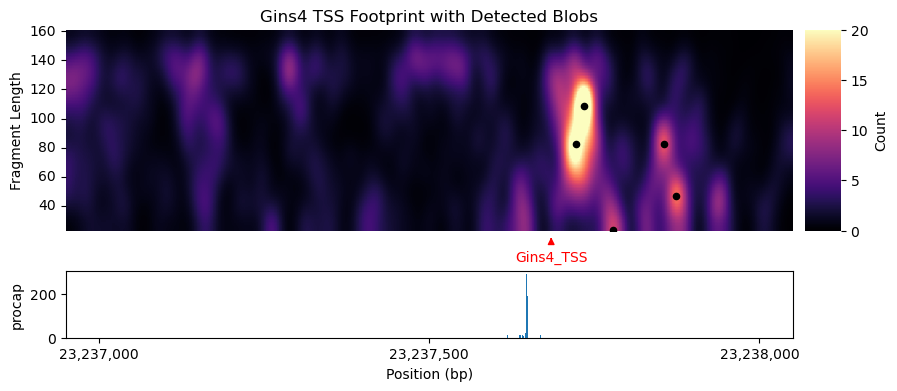

(131, 1001) (131,) (1001,)


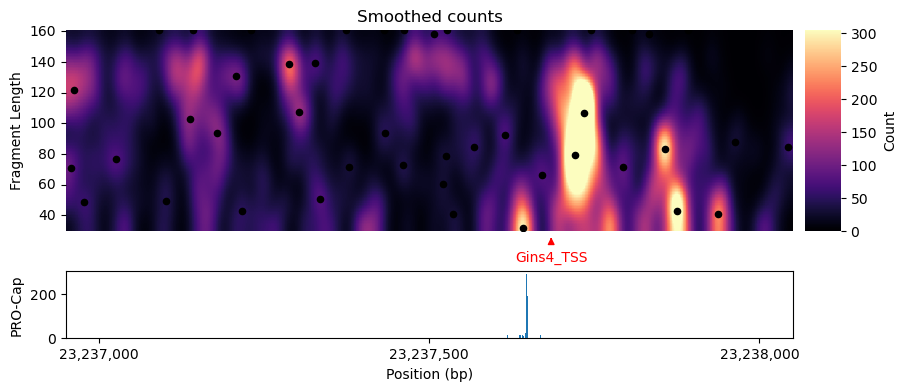

In [18]:

# Visualize a small region with detected footprints

chrom = 'chr8'
start_bp = 23_237_000
end_bp = 23_238_000

markers = {
    23_237_668: 'Gins4_TSS'
}

footprint, raw_total_counts, procap = \
    get_footprint_and_procap(fragment_counts_gz=counts_gz, 
                                procap_bw=procap_bw, 
                                fragment_len_min=30, fragment_len_max=160,
                                chrom=chrom, window_start=start_bp, window_end=end_bp, footprint_sigma=10)

# Print footprint and procap shape
print(footprint.shape, raw_total_counts.shape, procap.shape)

plot_count_matrix(footprint, named_positions=markers, tracks = {'PRO-Cap': procap}, 
                  title='Smoothed counts', xtick_spacing=500,
                  blobs = footprints, blob_color='black', blob_size=20)

In [ ]:
# Visualize another region with detected footprints

chrom = 'chr8'
start_bp = 85_024_500
end_bp = 85_027_500

footprint, raw_total_counts, procap = \
    get_footprint_and_procap(fragment_counts_gz=counts_gz, 
                                procap_bw=procap_bw,
                                fragment_len_min=25, fragment_len_max=160,
                                chrom=chrom, window_start=start_bp, window_end=end_bp, footprint_sigma=10)

# Print footprint and procap shape
print(footprint.shape, raw_total_counts.shape, procap.shape)

plot_count_matrix(footprint, tracks = {'PRO-Cap': procap}, 
                  title='Smoothed counts', xtick_spacing=500,
                  blobs = footprints[footprints["q_value"] <= 0.2], blob_color='black', blob_size=30)

(136, 3001) (136,) (3001,)


KeyError: 'q_value'

In [69]:
# Test conversion from fragment mid,size to start,end

import pysam
genome_fasta = "../genome/GRCh38.primary_assembly.genome.fa.gz"

tb = pysam.TabixFile('../test_data/mesc_microc_test.counts.tsv.gz')
records = tb.fetch(chrom, 22000800, 22000900)
for rec in records:
    chrom, pos, length, count = rec.split('\t')
    print(rec)
    # Convert pos, length to start, end
    start = float(pos) - (float(length)-1) / 2
    end = float(pos) + (float(length)-1) / 2
    print(chrom, start, end, count)


# 22000815
# 22000881

# chrom1  pos1            chrom2  pos2         strand1 strand2 pair_type  pos51         pos52    pos31       pos32
# chr8    22000881        chr8    23240613        -       -       UU      22000881      23240613 22000815        23240464

#chrom   midpoint        length  count
#chr8    22000848        67      1
#chr8    22000972        42      1
#chr8    22002392        125     1
#chr8    22002773        150     1

chr8	22000848	67	1
chr8 22000815.0 22000881.0 1


In [70]:
counts_gz

'../data/MicroC_3hrDMSO.counts.tsv.gz'

Getting valid windows...
Processing 8 windows using 4 cores...


Detecting footprints: 100%|██████████| 8/8 [00:05<00:00,  1.38it/s]


Detected 10 footprints across 8 windows.


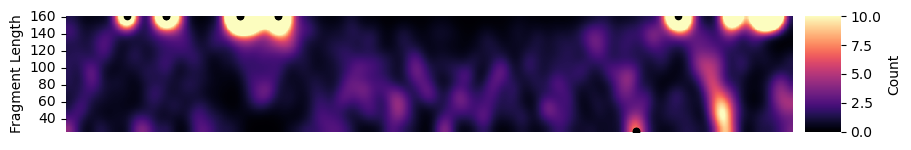

In [71]:
# Model sequence cut bias 1/3

import pysam
threshold = 5  # Minimum signal intensity to be considered part of a blob
sigma = 10.0       # Standard deviation for Gaussian smoothing
min_size = 5      # Minimum blob size in pixels

chrom = 'chr8'
start_bp = 23_230_000
end_bp = 23_230_999

footprints = detect_footprints(counts_gz, chromosomes=[(chrom, start_bp, end_bp)], window_size=200, pad=100, threshold=threshold, sigma=sigma,
                               fragment_len_min=25, fragment_len_max=160, scale_factor_dict=avg_by_len)

count_mat, _ = get_count_matrix(counts_gz, chrom, start_bp, end_bp, fragment_len_min=25, fragment_len_max=160, scale_factor_dict=avg_by_len, sigma=10)


plot_count_matrix(count_mat, blobs=footprints, blob_marker='o', blob_color='black', blob_size=20, 
                    xtick_spacing=500, figsize=(10, 1.5), vmax=10)



In [72]:
# Model sequence cut bias 2/3

import pysam

context_pad = 2

fasta = pysam.FastaFile(genome_fasta)
seq = fasta.fetch(chrom, start_bp-1, end_bp)
print(len(seq))
fasta.close()

# Create a pandas DataFrame with columns: 'position' (from start_bp to end_bp) and 'count' (initialized to 0)
positions = np.arange(start_bp+context_pad-1, end_bp-context_pad+1)
counts = np.zeros_like(positions)

# Generate a sequence context feature for each position in the window
contexts = []
for i in range(len(seq) - 2*context_pad+1):
    contexts.append(seq[i:i+context_pad] + '_' + seq[i+context_pad:i+2*context_pad])

df = pd.DataFrame({'position': positions, 'context': contexts, 'count': counts.astype(int)})
#print(df.head())
# Index on position
df = df.set_index('position')


# Add counts for each observed cut (i.e. fragment start and end)
tb = pysam.TabixFile(counts_gz)
records = tb.fetch(chrom, start_bp, end_bp)
i = 0
for rec in records:
    i = i + 1
    chrom, pos, length, count = rec.split('\t')
    # Convert pos, length to start, end
    frag_start = float(pos) - (float(length)-1) / 2
    frag_end = float(pos) + (float(length)-1) / 2
    try:
        df.loc[frag_start-1, 'count'] += int(count)
        df.loc[frag_end, 'count'] += int(count)
    except KeyError:
        # Fragment outside the window
        pass


# Remove rows of df where position appears within 100bp of a position in footprints
to_remove = set()
for p in footprints['position'].unique():
    to_remove.update(range(p - 100, p + 101))
df = df[~df.index.isin(to_remove)]


print(df.head)


1000
<bound method NDFrame.head of          context  count
position               
23230392   AC_CT      5
23230393   CC_TG     13
23230394   CT_GC      2
23230395   TG_CC     12
23230396   GC_CA     22
...          ...    ...
23230993   AT_GT      0
23230994   TG_TC      1
23230995   GT_CA      0
23230996   TC_AA      2
23230997   CA_AC      3

[347 rows x 2 columns]>


In [73]:
# Model sequence cut bias 3/3

# Summarize df by context: count number of occurances and total count 
context_counts = df.groupby('context')['count'].agg(['sum', 'count'])

print(context_counts)

         sum  count
context            
AA_AA      9      1
AA_AG     13      1
AA_AT      6      2
AA_CA      7      1
AA_CG      3      1
...      ...    ...
TT_GT      8      3
TT_TA     28      6
TT_TC     16      6
TT_TG     60      5
TT_TT     84     17

[154 rows x 2 columns]


In [74]:
# Model sequence cut bias - larger area - all steps

import pysam
threshold = 5  # Minimum signal intensity to be considered part of a blob
sigma = 10.0       # Standard deviation for Gaussian smoothing
min_size = 5      # Minimum blob size in pixels
genome_fasta = "../genome/GRCh38.primary_assembly.genome.fa.gz"

window_size = 100_000

context_pad = 2

chrom = 'chr8'
start = 20_000_000
end = 22_000_000


context_counts = pd.DataFrame()

# Get valid windows
windows = get_valid_windows(counts_gz, chromosomes=[(chrom, start, end)], window_size=window_size, window_overlap_bp=0, maxgap=1000, max_windows=None)


for chrom, start_bp, end_bp in windows:
    print(chrom, start_bp, end_bp)

    # Create a pandas DataFrame with columns: 'position' (from start_bp to end_bp) and 'count' (initialized to 0).
    positions = np.arange(start_bp+context_pad-1, end_bp-context_pad+1)
    counts = np.zeros_like(positions)

    # Generate a sequence context feature for each position in the window
    fasta = pysam.FastaFile(genome_fasta)
    seq = fasta.fetch(chrom, start_bp-1, end_bp)
    fasta.close()
    contexts = []
    for i in range(len(seq) - 2*context_pad+1):
        contexts.append(seq[i:i+context_pad] + '_' + seq[i+context_pad:i+2*context_pad])

    df = pd.DataFrame({'position': positions, 'context': contexts, 'count': counts.astype(int)})
    #print(df.head())
    # Index on position
    df = df.set_index('position')


    # Add counts for each observed cut (i.e. fragment start and end)
    tb = pysam.TabixFile(counts_gz)
    records = tb.fetch(chrom, start_bp, end_bp)
    i = 0
    for rec in records:
        i = i + 1
        chrom, pos, length, count = rec.split('\t')
        # Convert pos, length to start, end
        frag_start = float(pos) - (float(length)-1) / 2
        frag_end = float(pos) + (float(length)-1) / 2 
        try:
            df.loc[frag_start-1, 'count'] += int(count)
            df.loc[frag_end, 'count'] += int(count)
        except KeyError:
            # Fragment outside the window
            pass


    # Remove rows of df where position appears within 100bp of a position in footprints
    footprints = detect_footprints(counts_gz, chromosomes=[(chrom, start_bp, end_bp)], window_size=5000, pad=200, threshold=threshold, sigma=sigma,
                                fragment_len_min=25, fragment_len_max=160, scale_factor_dict=avg_by_len, quiet=True)
    to_remove = set()
    # If the footprints are empty, skip to the next window
    if not footprints.empty:
        for p in footprints['position'].unique():
            to_remove.update(range(p - 100, p + 101))
        df = df[~df.index.isin(to_remove)]

    # Summarize df by context: count number of occurances and total count. Concat to context_counts
    context_counts = pd.concat([context_counts, df.groupby('context')['count'].agg(['sum', 'count'])])

print(context_counts)

chr8 21676324 21776323
chr8 21837518 21937517
          sum  count
context             
AA_AA    1270    720
AA_AC     571    359
AA_AG     947    501
AA_AT     738    397
AA_CA     661    402
...       ...    ...
TT_GT     887    273
TT_TA     977    337
TT_TC    1136    390
TT_TG     999    375
TT_TT    2076    722

[512 rows x 2 columns]


In [75]:
# Model sequence cut bias - larger area - all steps (OPTIMIZED VERSION)

import pysam
import time
from collections import defaultdict

threshold = 5  # Minimum signal intensity to be considered part of a blob
sigma = 10.0       # Standard deviation for Gaussian smoothing
min_size = 5      # Minimum blob size in pixels
genome_fasta = "../genome/GRCh38.primary_assembly.genome.fa.gz"

# OPTIMIZATION 1: Use smaller window size for faster processing
window_size = 50_000  # Reduced from 100_000

context_pad = 2

chrom = 'chr8'
start = 10_000_000
end = 110_000_000

print(f"Processing {(end-start)/1e6:.1f} Mb region with {window_size/1000:.0f}kb windows...")
start_time = time.time()

context_counts = pd.DataFrame()

# Get valid windows
windows = get_valid_windows(counts_gz, chromosomes=[(chrom, start, end)], window_size=window_size, window_overlap_bp=0, maxgap=1000, max_windows=None)

# OPTIMIZATION 2: Open FASTA file once and keep it open
fasta = pysam.FastaFile(genome_fasta)
tb = pysam.TabixFile(counts_gz)

# OPTIMIZATION 3: Pre-detect all footprints for the entire region to avoid repeated calls
print("Pre-detecting footprints for entire region...")
all_footprints = detect_footprints(counts_gz, chromosomes=[(chrom, start, end)], 
                                  window_size=10000, pad=200, threshold=threshold, sigma=sigma,
                                  fragment_len_min=25, fragment_len_max=160, 
                                  scale_factor_dict=avg_by_len, quiet=True)

# Create a set of positions to exclude (within 100bp of footprints)
exclude_positions = set()
if not all_footprints.empty:
    for p in all_footprints['position'].unique():
        exclude_positions.update(range(int(p) - 100, int(p) + 101))

print(f"Processing {len(windows)} windows...")

for window_idx, (chrom, start_bp, end_bp) in enumerate(windows):
    if window_idx % 5 == 0:  # Progress update every 5 windows
        elapsed = time.time() - start_time
        print(f"Window {window_idx+1}/{len(windows)} ({chrom}:{start_bp}-{end_bp}) - {elapsed:.1f}s elapsed")

    # OPTIMIZATION 4: Vectorized sequence context generation
    seq = fasta.fetch(chrom, start_bp-1, end_bp)
    seq_len = len(seq)
    
    # Create positions array
    positions = np.arange(start_bp+context_pad-1, end_bp-context_pad+1)
    
    # OPTIMIZATION 5: Vectorized context creation using list comprehension
    contexts = [seq[i:i+context_pad] + '_' + seq[i+context_pad:i+2*context_pad] 
                for i in range(seq_len - 2*context_pad+1)]
    
    # OPTIMIZATION 6: Use defaultdict for faster counting
    position_counts = defaultdict(int)
    
    # Add counts for each observed cut (i.e. fragment start and end)
    records = tb.fetch(chrom, start_bp, end_bp)
    for rec in records:
        chrom_rec, pos, length, count = rec.split('\t')
        # Convert pos, length to start, end
        frag_start = int(float(pos) - (float(length)-1) / 2)
        frag_end = int(float(pos) + (float(length)-1) / 2)
        
        # Only add counts for positions within our window range
        if start_bp+context_pad-1 <= frag_start-1 <= end_bp-context_pad:
            position_counts[frag_start-1] += int(count)
        if start_bp+context_pad-1 <= frag_end <= end_bp-context_pad:
            position_counts[frag_end] += int(count)
    
    # OPTIMIZATION 7: Create DataFrame more efficiently
    counts_array = np.array([position_counts.get(pos, 0) for pos in positions])
    
    # Filter out positions near footprints
    valid_mask = ~np.isin(positions, list(exclude_positions))
    
    if valid_mask.sum() > 0:  # Only process if we have valid positions
        valid_positions = positions[valid_mask]
        valid_contexts = [contexts[i] for i in range(len(contexts)) if valid_mask[i]]
        valid_counts = counts_array[valid_mask]
        
        # Create DataFrame for this window
        window_df = pd.DataFrame({
            'position': valid_positions,
            'context': valid_contexts,
            'count': valid_counts
        })
        
        # Summarize by context and concatenate
        window_summary = window_df.groupby('context')['count'].agg(['sum', 'count'])
        context_counts = pd.concat([context_counts, window_summary])

# Close file handles
fasta.close()
tb.close()

elapsed_time = time.time() - start_time
print(f"\nCompleted in {elapsed_time:.1f} seconds ({elapsed_time/60:.1f} minutes)")
print(f"Processed {len(windows)} windows, {(end-start)/1e6:.1f} Mb total")
print(f"Speed: {(end-start)/1e6/elapsed_time*60:.1f} Mb/minute")

Processing 100.0 Mb region with 50kb windows...
Pre-detecting footprints for entire region...


/Users/martin/miniforge3/envs/footprint-tools/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/martin/miniforge3/envs/footprint-tools/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/martin/miniforge3/envs/footprint-tools/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/martin/miniforge3/envs/footprint-tools/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped

Processing 1658 windows...
Window 1/1658 (chr8:10000002-10050001) - 642.2s elapsed
Window 6/1658 (chr8:10331560-10381559) - 650.9s elapsed
Window 11/1658 (chr8:10581560-10631559) - 659.5s elapsed
Window 16/1658 (chr8:10831560-10881559) - 668.2s elapsed
Window 21/1658 (chr8:11081560-11131559) - 676.8s elapsed
Window 26/1658 (chr8:11331560-11381559) - 685.4s elapsed
Window 31/1658 (chr8:11581560-11631559) - 694.2s elapsed
Window 36/1658 (chr8:11831560-11881559) - 703.1s elapsed
Window 41/1658 (chr8:12085322-12135321) - 711.8s elapsed
Window 46/1658 (chr8:12335322-12385321) - 720.3s elapsed
Window 51/1658 (chr8:12585322-12635321) - 729.1s elapsed
Window 56/1658 (chr8:12835322-12885321) - 737.8s elapsed
Window 61/1658 (chr8:13085322-13135321) - 746.7s elapsed
Window 66/1658 (chr8:13335322-13385321) - 755.7s elapsed
Window 71/1658 (chr8:13592740-13642739) - 764.5s elapsed
Window 76/1658 (chr8:13917104-13967103) - 773.2s elapsed
Window 81/1658 (chr8:14292734-14342733) - 781.9s elapsed
Window

             sum   count
context                 
AA_AA    2132525  692746
AA_AC     800548  260236
AA_AG     989335  321142
AA_AT    1412380  458045
AA_CA     849956  276433
...          ...     ...
TT_GT     781346  252962
TT_TA    1162705  375184
TT_TC    1034308  335971
TT_TG    1054385  343159
TT_TT    2158613  696755

[272 rows x 2 columns]


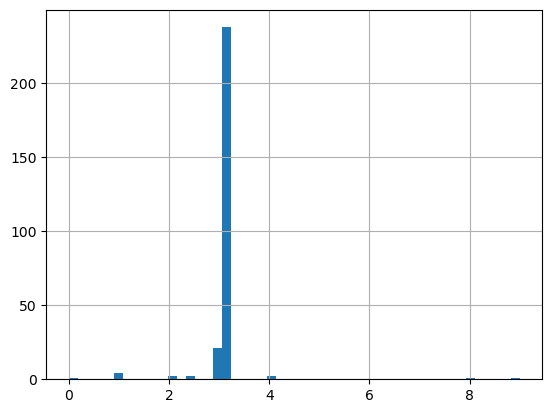

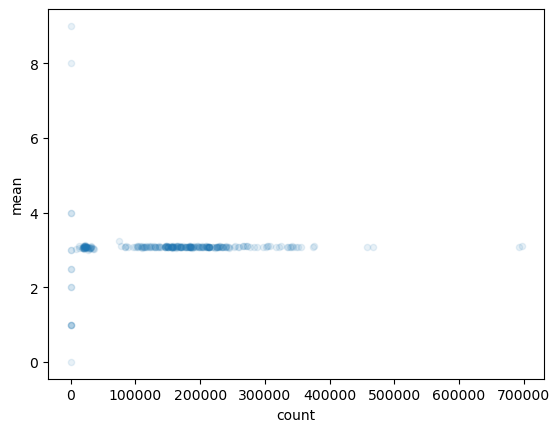

In [76]:
# Combine rows in context_counts where the context is the same.
context_counts = context_counts.groupby(context_counts.index).sum()
print(context_counts)

context_counts['mean'] = context_counts['sum'] / context_counts['count']

# Plot a histogram of mean
context_counts['mean'].hist(bins=50)
plt.show()

# Make a mean vs count plot
context_counts.plot.scatter(x='count', y='mean', alpha=0.1)
plt.show()

<Figure size 600x200 with 0 Axes>

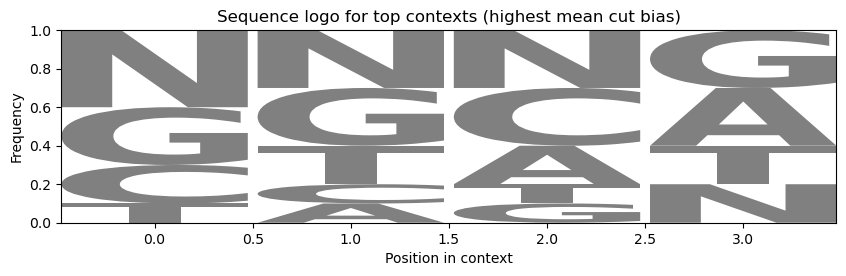

<Figure size 600x200 with 0 Axes>

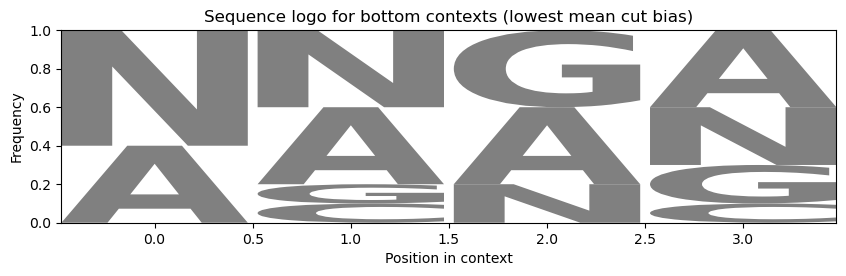

In [77]:
# Make sequence logos for top_contexts

import logomaker

# Get the context column for the top and bottom 10 rows
top_contexts = context_counts.sort_values(by='mean', ascending=False).head(10).index.tolist()
bottom_contexts = context_counts.sort_values(by='mean', ascending=True).head(10).index.tolist()

def context_to_df(contexts):
    """
    Convert a list of sequence contexts (e.g. 'AC_GT') to a DataFrame suitable for logomaker.
    Assumes context is of the form 'NN_NN' for context_pad=2.
    """
    # Split context into left and right parts
    split_contexts = [c.split('_') for c in contexts]
    # Flatten to a list of nucleotides
    seqs = [''.join(parts) for parts in split_contexts]
    # Build DataFrame
    df = pd.DataFrame([list(seq) for seq in seqs])
    return df

# Prepare DataFrame for sequence logo
top_df = context_to_df(top_contexts)
bottom_df = context_to_df(bottom_contexts)

# Count frequency of each base at each position
top_counts_df = top_df.apply(pd.Series.value_counts).fillna(0)
bottom_counts_df = bottom_df.apply(pd.Series.value_counts).fillna(0)

# Normalize to get probabilities
top_probs_df = top_counts_df / top_counts_df.sum()
bottom_probs_df = bottom_counts_df / bottom_counts_df.sum()

# Plot top sequence logos
plt.figure(figsize=(6,2))
logomaker.Logo(top_probs_df.T)
plt.title("Sequence logo for top contexts (highest mean cut bias)")
plt.xlabel("Position in context")
plt.ylabel("Frequency")
plt.show()

# Plot bottom sequence logos
plt.figure(figsize=(6,2))
logomaker.Logo(bottom_probs_df.T)
plt.title("Sequence logo for bottom contexts (lowest mean cut bias)")
plt.xlabel("Position in context")
plt.ylabel("Frequency")
plt.show()







In [78]:
# What are the contexts with a mean > 3.6?
high_contexts = context_counts[context_counts['mean'] > 3.6].index.tolist()
print(high_contexts)

['GA_NN', 'NN_NT', 'NN_TA', 'NT_AA']



Benchmarking window size: 1,000 bp
Processing 10000 windows...
Window size: 1,000 bp
Number of windows: 10000
Processing time: 471.90 seconds
Peak memory usage: 20.23 MB
Number of blobs detected: 15903

Benchmarking window size: 5,000 bp
Processing 2000 windows...
Window size: 5,000 bp
Number of windows: 2000
Processing time: 1079.14 seconds
Peak memory usage: 138.25 MB
Number of blobs detected: 15903

Benchmarking window size: 10,000 bp
Processing 1000 windows...
Window size: 10,000 bp
Number of windows: 1000
Processing time: 146.14 seconds
Peak memory usage: 35.72 MB
Number of blobs detected: 15903

Benchmarking window size: 25,000 bp
Processing 400 windows...
Window size: 25,000 bp
Number of windows: 400
Processing time: 138.14 seconds
Peak memory usage: 151.83 MB
Number of blobs detected: 15903

Benchmarking window size: 50,000 bp
Processing 200 windows...
Window size: 50,000 bp
Number of windows: 200
Processing time: 140.73 seconds
Peak memory usage: 433.23 MB
Number of blobs det

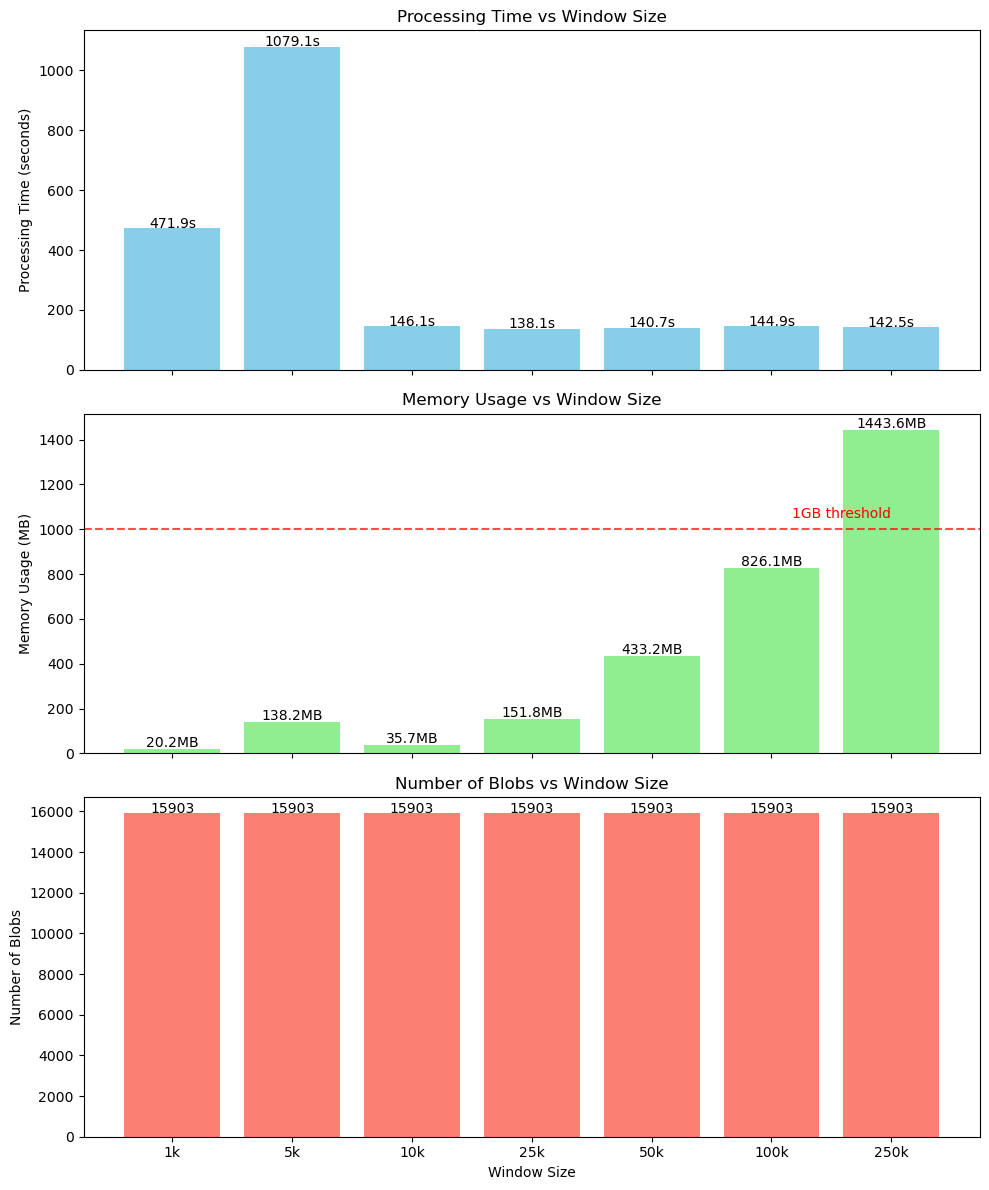


Optimal window size: 25,000.0 bp
Processing time: 138.14 seconds
Memory usage: 151.83 MB
Number of blobs: 15903.0

This window size provides the best balance between processing speed and memory usage while staying under 1GB.


In [79]:
# Benchmark different window sizes for blob detection across a large genomic region
# Using a fixed 200bp overlap between adjacent windows to ensure consistent detection of features at window boundaries
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from memory_profiler import memory_usage

def process_region_with_window(chrom, start, end, window_size, pad=200, threshold=5.0, sigma=1.0, min_size=5):
    """
    Process a genomic region using sliding windows of specified size.
    Windows have a fixed 200bp overlap between adjacent windows.
    
    Parameters
    ----------
    chrom : str
        Chromosome name
    start : int
        Start position of the region
    end : int
        End position of the region
    window_size : int
        Size of each window in base pairs
    pad : int
        Padding to add to each side of the window
    threshold : float
        Threshold for blob detection
    sigma : float
        Sigma for Gaussian smoothing in blob detection
    min_size : int
        Minimum blob size in pixels
        
    Returns
    -------
    tuple
        (all_blobs, processing_time, max_memory)
    """
    # Create windows
    windows = []
    for i in range(start, end, window_size):
        window_end = min(i + window_size-1, end)
        windows.append((chrom, i, window_end))
    
    # Initialize empty DataFrame for blobs
    all_blobs = pd.DataFrame()
    
    # Start timing
    start_time = time.time()
    
    # Define the function to be memory profiled
    def process_windows():
        nonlocal all_blobs
        for chrom, window_start, window_end in windows:
            # Get count matrix for this window
            try:
                footprint, _ = get_count_matrix(
                    counts_gz=counts_gz, 
                    chrom=chrom, 
                    window_start=window_start-pad, 
                    window_end=window_end+pad, 
                    fragment_len_min=30, 
                    fragment_len_max=150, 
                    scale_factor_dict=avg_by_len, 
                    sigma=10
                )
                
                # Detect blobs
                window_blobs = detect_blobs_matrix(
                    footprint_matrix=footprint,
                    threshold=threshold,
                    min_size=min_size
                )
                
                # Add window information to blobs
                if not window_blobs.empty:
                    window_blobs['window_start'] = window_start
                    window_blobs['window_end'] = window_end
                    
                    # Append to all_blobs
                    window_blobs = window_blobs[(window_blobs['position'] >= window_start) & (window_blobs['position'] <= window_end)]
                    all_blobs = pd.concat([all_blobs, window_blobs], ignore_index=True)
            except Exception as e:
                print(f"Error processing window {chrom}:{window_start}-{window_end}: {e}")
    
    # Run the function with memory profiling
    mem_usage = memory_usage(process_windows, interval=0.1, timeout=None, max_iterations=1)
    
    # Calculate processing time
    processing_time = time.time() - start_time
    
    # Calculate max memory usage (in MB)
    max_memory = max(mem_usage) - min(mem_usage)
    
    return all_blobs, processing_time, max_memory

# Define the region to process (chromosome 8 from 20,000,000 to 40,000,000)
chrom = 'chr8'
start_pos = 20_000_000
end_pos = 30_000_000

# Define window sizes to test (in base pairs)
window_sizes = [1_000, 5_000, 10_000, 25_000, 50_000, 100_000, 250_000]

# Initialize results dictionary
results = {
    'window_size': [],
    'num_windows': [],
    'processing_time': [],
    'memory_usage': [],
    'num_blobs': []
}

# Run benchmarks for each window size
for window_size in window_sizes:
    print(f"\nBenchmarking window size: {window_size:,} bp")
        
    # Calculate number of windows
    num_windows = (end_pos - start_pos) // window_size
    if (end_pos - start_pos) % window_size > 0:
        num_windows += 1
    
    print(f"Processing {num_windows} windows...")
    
    # Process the region
    blobs, proc_time, max_memory = process_region_with_window(
        chrom=chrom,
        start=start_pos,
        end=end_pos,
        window_size=window_size,
        pad=200
    )
    
    # Store results
    results['window_size'].append(window_size)
    results['num_windows'].append(num_windows)
    results['processing_time'].append(proc_time)
    results['memory_usage'].append(max_memory)
    results['num_blobs'].append(len(blobs))
    
    print(f"Window size: {window_size:,} bp")
    print(f"Number of windows: {num_windows}")
    print(f"Processing time: {proc_time:.2f} seconds")
    print(f"Peak memory usage: {max_memory:.2f} MB")
    print(f"Number of blobs detected: {len(blobs)}")

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Display results table
print("\nBenchmark Results:")
print(results_df.to_string(index=False))

# Create visualization of results
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Format window sizes for display
window_sizes_labels = [f"{size/1000:.0f}k" for size in results['window_size']]

# Plot processing time
ax1.bar(window_sizes_labels, results['processing_time'], color='skyblue')
ax1.set_ylabel('Processing Time (seconds)')
ax1.set_title('Processing Time vs Window Size')
for i, v in enumerate(results['processing_time']):
    ax1.text(i, v + 1, f"{v:.1f}s", ha='center')

# Plot memory usage
ax2.bar(window_sizes_labels, results['memory_usage'], color='lightgreen')
ax2.set_ylabel('Memory Usage (MB)')
ax2.set_title('Memory Usage vs Window Size')
# Add a horizontal line at 1000 MB (1GB)
ax2.axhline(y=1000, color='red', linestyle='--', alpha=0.7)
ax2.text(len(window_sizes_labels)-1, 1050, '1GB threshold', color='red', ha='right')
for i, v in enumerate(results['memory_usage']):
    ax2.text(i, v + 10, f"{v:.1f}MB", ha='center')

# Plot number of blobs
ax3.bar(window_sizes_labels, results['num_blobs'], color='salmon')
ax3.set_ylabel('Number of Blobs')
ax3.set_xlabel('Window Size')
ax3.set_title('Number of Blobs vs Window Size')
for i, v in enumerate(results['num_blobs']):
    ax3.text(i, v + 5, str(v), ha='center')

plt.tight_layout()
plt.show()

# Determine optimal window size
# The optimal window size balances processing speed and memory usage
# Larger windows (25-50kb) typically process faster as they require fewer total windows
# However, memory usage increases with window size, so we need to stay under 1GB
# With fixed 200bp overlap, larger windows also have less redundant processing compared to 50% overlap
# Find window sizes that keep memory usage under 1GB
valid_sizes = results_df[results_df['memory_usage'] < 1000]

if not valid_sizes.empty:
    # Find the window size with the best processing time among valid sizes
    optimal_idx = valid_sizes['processing_time'].idxmin()
    optimal_size = valid_sizes.iloc[optimal_idx]['window_size']
    optimal_time = valid_sizes.iloc[optimal_idx]['processing_time']
    optimal_memory = valid_sizes.iloc[optimal_idx]['memory_usage']
    
    print(f"\nOptimal window size: {optimal_size:,} bp")
    print(f"Processing time: {optimal_time:.2f} seconds")
    print(f"Memory usage: {optimal_memory:.2f} MB")
    print(f"Number of blobs: {valid_sizes.iloc[optimal_idx]['num_blobs']}")
    print("\nThis window size provides the best balance between processing speed and memory usage while staying under 1GB.")
else:
    print("\nAll tested window sizes exceed 1GB of memory usage.")
    print("Consider using smaller window sizes or optimizing the blob detection algorithm for better memory efficiency.")